# 📊 Análise de Cirurgias CCP (Notebook Base)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Ajuste visual
sns.set(style='whitegrid')

: 

In [109]:
import plotly.express as px
import streamlit as st



In [76]:
# 📥 Carregar os dados
df = pd.read_excel("Todas Cirurgias-CCP.xlsx", sheet_name="Plan1")

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATA              1430 non-null   datetime64[ns]
 1   PACIENTE          1430 non-null   object        
 2   MV                1430 non-null   object        
 3   CHEFE             1430 non-null   object        
 4   RESIDENTE         1429 non-null   object        
 5   CIRURGIA          1430 non-null   object        
 6   ANEST             1430 non-null   object        
 7   ANESTESISTA       1420 non-null   object        
 8   INICIO            1429 non-null   object        
 9   FIM               1426 non-null   object        
 10  Mês               0 non-null      float64       
 11  Ano               0 non-null      float64       
 12  Duração em horas  0 non-null      float64       
dtypes: datetime64[ns](1), float64(3), object(9)
memory usage: 145.4+ KB


In [78]:
df.drop(columns=['ANESTESISTA', 'RESIDENTE', 'Mês', 'Ano', "Duração em horas"], inplace=True)


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1430 entries, 0 to 1429
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATA       1430 non-null   datetime64[ns]
 1   PACIENTE   1430 non-null   object        
 2   MV         1430 non-null   object        
 3   CHEFE      1430 non-null   object        
 4   CIRURGIA   1430 non-null   object        
 5   ANEST      1430 non-null   object        
 6   INICIO     1429 non-null   object        
 7   FIM        1426 non-null   object        
dtypes: datetime64[ns](1), object(7)
memory usage: 89.5+ KB


In [80]:
df['CHEFE'].value_counts()

CHEFE
RAFAEL        325
PABLO         263
MARCELO       260
FRANCISCO     259
ERICA         135
VICTOR        134
JOSE GOIS      19
SANDRA         19
MARCELO         6
ERICA           3
JOSE            3
JOAO            3
RAFEL           1
Name: count, dtype: int64

In [81]:
# 1. Remover espaços extras e padronizar para maiúsculas
df['CHEFE'] = df['CHEFE'].str.strip().str.upper()

In [82]:
# 2. Corrigir nomes específicos
df['CHEFE'] = df['CHEFE'].replace({
    'RAFEL': 'RAFAEL',
    'JOSE': 'JOSE GOIS',      # se for erro de acento

})

In [83]:
df['CHEFE'].value_counts()

CHEFE
RAFAEL       326
MARCELO      266
PABLO        263
FRANCISCO    259
ERICA        138
VICTOR       134
JOSE GOIS     22
SANDRA        19
JOAO           3
Name: count, dtype: int64

In [84]:
df['CIRURGIA '].value_counts()

CIRURGIA 
TIREOIDECTOMIA TOTAL                                                                                                                                                                                            256
TIREOIDECTOMIA TOTAL + LINFADENECTOMIA RECORRENCIAL                                                                                                                                                              89
TRAQUEOSTOMIA                                                                                                                                                                                                    51
LARINGECTOMIA PARCIAL                                                                                                                                                                                            35
GLOSSECTOMIA PARCIAL                                                                                                                          

In [87]:
df_novo1 = df.copy()

In [ ]:


# Verificar os dados para as colunas INÍCIO e FINAL
print(df_novo1[['INICIO', 'FIM']].head())

# Garantir que as colunas INÍCIO e FINAL estão no formato datetime
df_novo1['INICIO'] = pd.to_datetime(df_novo1['INICIO'], errors='coerce')
df_novo1['FIM'] = pd.to_datetime(df['FIM'], errors='coerce')

# Calcular a diferença de tempo em minutos
df_novo1['Duração em minutos'] = (df_novo1['FIM'] - df_novo1['INICIO']).dt.total_seconds() / 60

# Verificar as primeiras linhas do DataFrame para confirmar
print(df_novo1[['INICIO', 'FIM', 'Duração em minutos']].head())




                INICIO                  FIM
0  1900-01-01 07:55:28  1900-01-01 09:05:28
1  1900-01-01 10:00:28  1900-01-01 12:50:28
2  1900-01-01 13:05:28  1900-01-01 14:35:28
3  1900-01-01 08:30:28  1900-01-01 10:10:28
4  1900-01-01 08:24:28  1900-01-01 10:10:28
               INICIO                 FIM  Duração em minutos
0 1900-01-01 07:55:28 1900-01-01 09:05:28                70.0
1 1900-01-01 10:00:28 1900-01-01 12:50:28               170.0
2 1900-01-01 13:05:28 1900-01-01 14:35:28                90.0
3 1900-01-01 08:30:28 1900-01-01 10:10:28               100.0
4 1900-01-01 08:24:28 1900-01-01 10:10:28               106.0


In [93]:
df_novo1['Duração em minutos'].describe()

count    1423.000000
mean      131.664090
std       105.841659
min      -470.000000
25%        60.000000
50%       115.000000
75%       165.000000
max       855.000000
Name: Duração em minutos, dtype: float64

In [100]:
import pandas as pd

# Verificar a diferença de tempo em minutos entre INICIO e FIM
df_novo1['Duração em minutos'] = (df_novo1['FIM'] - df_novo1['INICIO']).dt.total_seconds() / 60

# Verificar se há valores negativos na coluna 'Duração em minutos'
valores_negativos = df_novo1[df_novo1['Duração em minutos'] < 0]

# Exibir quantos registros possuem valores negativos e quais são esses registros
print(f"Quantidade de valores negativos: {valores_negativos.shape[0]}")
print(valores_negativos[['INICIO', 'FIM', 'Duração em minutos']])


Quantidade de valores negativos: 3
                  INICIO                 FIM  Duração em minutos
696  1900-01-01 13:35:28 1900-01-01 12:45:28               -50.0
851  1900-01-01 08:00:28 1900-01-01 00:10:28              -470.0
1184 1900-01-01 10:20:28 1900-01-01 10:05:28               -15.0


In [101]:


# Excluir as linhas onde a Duração em minutos é negativa
df_novo1 = df_novo1[df_novo1['Duração em minutos'] >= 0]

# Verificar o resultado
print(f"Quantidade de linhas após remoção: {df_novo1.shape[0]}")


Quantidade de linhas após remoção: 1420


In [ ]:
df.drop(columns=['ANESTESISTA', 'RESIDENTE', 'Mês', 'Ano', "Duração em horas"], inplace=True)


✅ 1. Criar coluna de mês e ano juntos (formato 2024-04)


In [65]:
df['MES_ANO'] = df['DATA'].dt.to_period('M').astype(str)


📊 2. Agrupar e contar por mês

In [66]:
frequencia_mensal = df['MES_ANO'].value_counts().sort_index()


📈 3. Plotar o gráfico de frequência


In [67]:
# 1. Criar coluna mês/ano se ainda não existir
df['MES_ANO'] = df['DATA'].dt.to_period('M').astype(str)

# 2. Agrupar e contar
frequencia_mensal = df['MES_ANO'].value_counts().sort_index()
frequencia_df = pd.DataFrame({'MES_ANO': frequencia_mensal.index, 'TOTAL': frequencia_mensal.values})

# 3. Criar gráfico interativo
fig = px.line(frequencia_df, x='MES_ANO', y='TOTAL',
              title='📈 Tendência de Cirurgias por Mês',
              labels={'MES_ANO': 'Mês/Ano', 'TOTAL': 'Número de Cirurgias'},
              markers=True)

fig.update_layout(xaxis_tickangle=-45)
fig.show()



In [103]:
import pandas as pd

# Definir uma função para categorizar os tempos
def categorize_time(row):
    if row['Duração em minutos'] < 60:  # Menos de 1 hora
        return 'Menor que 1h'
    elif 60 <= row['Duração em minutos'] < 180:  # Entre 1 e 3 horas
        return '1-3h'
    elif 180 <= row['Duração em minutos'] < 360:  # Entre 3 e 6 horas
        return '3-6h'
    elif 360 <= row['Duração em minutos'] < 480:  # Entre 6 e 8 horas
        return '6-8h'
    else:  # Maior que 8 horas
        return '>8h'

# Aplicar a função para criar uma nova coluna 'Intervalo de Tempo'
df_novo1['Intervalo de Tempo'] = df_novo1.apply(categorize_time, axis=1)

# Verificar os resultados
print(df_novo1[['INICIO', 'FIM', 'Duração em minutos', 'Intervalo de Tempo']].head())

# Contagem de quantas cirurgias há em cada intervalo
print(df_novo1['Intervalo de Tempo'].value_counts())


               INICIO                 FIM  Duração em minutos  \
0 1900-01-01 07:55:28 1900-01-01 09:05:28                70.0   
1 1900-01-01 10:00:28 1900-01-01 12:50:28               170.0   
2 1900-01-01 13:05:28 1900-01-01 14:35:28                90.0   
3 1900-01-01 08:30:28 1900-01-01 10:10:28               100.0   
4 1900-01-01 08:24:28 1900-01-01 10:10:28               106.0   

  Intervalo de Tempo  
0               1-3h  
1               1-3h  
2               1-3h  
3               1-3h  
4               1-3h  
Intervalo de Tempo
1-3h            784
Menor que 1h    333
3-6h            246
6-8h             40
>8h              17
Name: count, dtype: int64


C:\Users\franc\AppData\Local\Temp\ipykernel_3524\2724903621.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



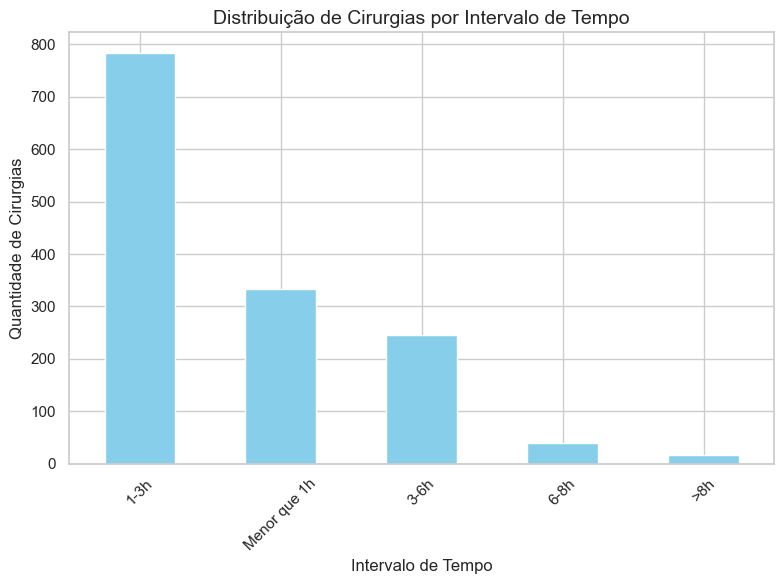

In [104]:
import matplotlib.pyplot as plt

# Contagem de cirurgias em cada intervalo de tempo
intervalo_contagem = df_novo1['Intervalo de Tempo'].value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
intervalo_contagem.plot(kind='bar', color='skyblue')

# Adicionar título e rótulos
plt.title('Distribuição de Cirurgias por Intervalo de Tempo', fontsize=14)
plt.xlabel('Intervalo de Tempo', fontsize=12)
plt.ylabel('Quantidade de Cirurgias', fontsize=12)

# Exibir o gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# 🏷️ Agrupar procedimentos padronizados
import re

def agrupar_procedimentos(cirurgia):
    if 'TIREOIDECTOMIA TOTAL' in cirurgia and (
        'LINFADENECTOMIA' in cirurgia or 'ESVAZIAMENTO' in cirurgia or
        'RECORRENCIA' in cirurgia or 'RECORRENCIAL' in cirurgia
    ):
        return 'TIREOIDECTOMIA TOTAL + ESV LN'
    elif 'TIREOIDECTOMIA TOTAL' in cirurgia:
        return 'TIREOIDECTOMIA TOTAL'
    elif 'TIREOIDECTOMIA PARCIAL' in cirurgia:
        return 'TIREOIDECTOMIA PARCIAL'
    elif re.search(r'TROCA.*PR[ÓO]TESE.*FONAT', cirurgia):
        return 'TROCA DE PRÓTESE FONATÓRIA'
    elif re.search(r'RECONSTRU[ÇC][AÃ]O.*FONAT', cirurgia):
        return 'RECONSTRUÇÃO PARA FONAÇÃO'
    return cirurgia

df['Procedimento Agrupado'] = df['CIRURGIA'].apply(agrupar_procedimentos)
df['Ano_Mes'] = df['DATA'].dt.to_period('M').astype(str)
df.head()